# Fase 1: Análisis Exploratorio

Online Retail II — 1.067.371 transacciones de un minorista online británico de artículos
de regalo, entre diciembre de 2009 y diciembre de 2011. Base de clientes mixta: consumidor
final y mayorista.

Objetivo de esta fase: entender los datos, limpiarlos con criterio explícito y dejar
preparado el esquema de ventanas deslizantes que usará la Fase 2. Cada decisión de
limpieza se justifica en la celda que la aplica, con el coste que tiene en filas e ingresos.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))  # tfm_pipeline.py vive en src/, no junto al notebook
import tfm_pipeline as tfm

tfm.setup_notebook()

LOOKBACK_MONTHS = tfm.LOOKBACK_MONTHS   # 6 meses de histórico para features
HORIZON_DAYS = tfm.HORIZON_DAYS         # 90 días de horizonte de predicción

In [2]:
# La descarga de UCI usa la nomenclatura antigua de columnas; se normaliza a la oficial.
df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='ISO-8859-1').rename(columns={
    'InvoiceNo': 'Invoice', 'UnitPrice': 'Price', 'CustomerID': 'Customer ID',
})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Amount'] = df['Quantity'] * df['Price']

print(f"Filas: {len(df):,} · Columnas: {df.shape[1]} · "
      f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(f"Periodo: {df['InvoiceDate'].min().date()} a {df['InvoiceDate'].max().date()}\n")
print(df.dtypes.to_string())

Filas: 1,067,371 · Columnas: 9 · Memoria: 325 MB
Periodo: 2009-12-01 a 2011-12-09

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Amount                float64


## Calidad de los datos

In [3]:
faltantes = (pd.DataFrame({'Faltantes': df.isnull().sum()})
             .assign(**{'%': lambda d: (d.Faltantes / len(df) * 100).round(2)})
             .query('Faltantes > 0').sort_values('Faltantes', ascending=False))
print(faltantes.to_string())

anomalias = pd.DataFrame([
    ('Quantity < 0 (devoluciones)', (df.Quantity < 0).sum()),
    ('Quantity == 0', (df.Quantity == 0).sum()),
    ('Price <= 0', (df.Price <= 0).sum()),
    ('Facturas de cancelación (Invoice empieza por C)',
     df.Invoice.astype(str).str.startswith('C').sum()),
    ('Ajustes contables (Invoice empieza por A)',
     df.Invoice.astype(str).str.startswith('A').sum()),
    ('Sin Customer ID', df['Customer ID'].isna().sum()),
], columns=['Situación', 'Filas'])
anomalias['% del total'] = (anomalias.Filas / len(df) * 100).round(2)
print(f"\n{anomalias.to_string(index=False)}")

# La proporción de facturas de cancelación se imprime abajo, no se afirma aquí. La Fase 2
# las excluye del recuento de compras (`frequency`) y las contabiliza aparte en
# `return_rate`: mezclar ambas señales en una sola variable falsea el ticket medio.
print(f"\nFacturas distintas: {df.Invoice.nunique():,}")
print(f"  de las cuales de cancelación: "
      f"{df.loc[df.Invoice.astype(str).str.startswith('C'), 'Invoice'].nunique():,} "
      f"({df.loc[df.Invoice.astype(str).str.startswith('C'), 'Invoice'].nunique() / df.Invoice.nunique():.1%})")

             Faltantes      %
Customer ID     243007  22.77
Description       4382   0.41



                                      Situación  Filas  % del total
                    Quantity < 0 (devoluciones)  22950         2.15
                                  Quantity == 0      0         0.00
                                     Price <= 0   6207         0.58
Facturas de cancelación (Invoice empieza por C)  19494         1.83
      Ajustes contables (Invoice empieza por A)      6         0.00
                                Sin Customer ID 243007        22.77

Facturas distintas: 53,628


  de las cuales de cancelación: 8,292 (15.5%)


### Precios no positivos

Antes de eliminar nada conviene saber qué son esas 6.207 filas. No son un bloque homogéneo:
sólo el 56% coincide con devoluciones.

In [4]:
raros = df[df.Price <= 0]
print(f"Filas con Price <= 0: {len(raros):,}")
print(f"  ...que además son devoluciones (Quantity < 0): {(raros.Quantity < 0).mean():.1%}")
print(f"  ...sin Customer ID: {raros['Customer ID'].isna().mean():.1%}\n")
print("Descripciones más frecuentes:")
print(raros.Description.fillna('(vacío)').value_counts().head(8).to_string())

Filas con Price <= 0: 6,207
  ...que además son devoluciones (Quantity < 0): 55.7%
  ...sin Customer ID: 98.9%

Descripciones más frecuentes:
Description
(vacío)                  4382
check                     162
?                          92
damages                    84
damaged                    81
found                      28
missing                    27
sold as set on dotcom      20


Se distinguen cuatro grupos, y sólo dos se eliminan:

| Grupo | Decisión |
|---|---|
| Ajustes contables de deuda incobrable (`Invoice` empieza por `A`) | **Eliminar** — no son transacciones de cliente |
| Filas `Manual` / `test` **con** `Price <= 0` | **Eliminar** — mismas etiquetas con precio válido sí son ventas reales y se conservan |
| Mermas y ajustes de almacén | Se eliminan solas al filtrar por `Customer ID` |
| Regalos y muestras a cliente identificado (`Price = 0`, `Quantity > 0`) | **Conservar** — se marcan como `is_free_gift`; son gestión de relación, no error |

In [5]:
n0 = len(df)
df = df[~df.Invoice.astype(str).str.startswith('A', na=False)]
df = df[~(df.Description.isin(['Manual', 'This is a test product.']) & (df.Price <= 0))]
print(f"Eliminadas por ajuste contable o prueba: {n0 - len(df):,}")

# El coste de exigir Customer ID se mide ANTES de filtrar, sobre el mismo
# dataframe: recargar el CSV crudo para recalcularlo daría un denominador distinto.
ingresos_totales = df.Amount.sum()
ingresos_anonimos = df.loc[df['Customer ID'].isna(), 'Amount'].sum()
pct_ingresos_anonimos = ingresos_anonimos / ingresos_totales

n1 = len(df)
df = df[df['Customer ID'].notna()].copy()
df['Customer ID'] = df['Customer ID'].astype(int)
print(f"Eliminadas por falta de Customer ID: {n1 - len(df):,} ({(n1 - len(df))/n1:.1%})")
print(f"\nDataset limpio: {len(df):,} filas · {df['Customer ID'].nunique():,} clientes")

# Estas cifras se citan en las limitaciones de la Fase 5. Se guardan aquí, en el
# único sitio donde se calculan, para que ninguna fase posterior las repita a mano.
calidad = {
    'filas_crudas': n0,
    'filas_limpias': len(df),
    'clientes_limpios': int(df['Customer ID'].nunique()),
    'pct_filas_sin_customer_id': round((n1 - len(df)) / n1 * 100, 1),
    'ingresos_totales': round(ingresos_totales, 2),
    'ingresos_anonimos': round(ingresos_anonimos, 2),
    'pct_ingresos_anonimos': round(pct_ingresos_anonimos * 100, 1),
}

Eliminadas por ajuste contable o prueba: 15
Eliminadas por falta de Customer ID: 243,001 (22.8%)

Dataset limpio: 824,355 filas · 5,940 clientes


### Coste de excluir las compras anónimas

Filtrar por `Customer ID` es obligatorio para cualquier análisis por cliente, pero tiene un
precio en cobertura de negocio que conviene dejar cuantificado.

In [6]:
print(f"Ingresos totales (tras descartar ajustes contables): £{ingresos_totales:,.0f}")
print(f"Ingresos de compras anónimas                     : £{ingresos_anonimos:,.0f} "
      f"({pct_ingresos_anonimos:.1%})")
print(f"\nEse {pct_ingresos_anonimos:.1%} de los ingresos queda fuera de toda acción de "
      f"retención personalizada.")

Ingresos totales (tras descartar ajustes contables): £19,434,865
Ingresos de compras anónimas                     : £2,786,572 (14.3%)

Ese 14.3% de los ingresos queda fuera de toda acción de retención personalizada.


### Variables derivadas

`is_cancellation` se detecta con `C` mayúscula, que es como el dataset codifica las facturas
anuladas. En este dataset toda cancelación es además una devolución, por lo que ambas señales
son idénticas y sólo se conserva una en la modelización: mantener las dos añadiría
una variable redundante sin información nueva.

In [7]:
df['is_return'] = (df.Quantity < 0).astype(int)
df['is_cancellation'] = df.Invoice.astype(str).str.startswith('C', na=False).astype(int)
df['is_free_gift'] = ((df.Price == 0) & (df.Quantity > 0)).astype(int)

print(f"Devoluciones     : {df.is_return.sum():,} ({df.is_return.mean():.2%})")
print(f"Cancelaciones    : {df.is_cancellation.sum():,} ({df.is_cancellation.mean():.2%})")
print(f"Regalos/muestras : {df.is_free_gift.sum():,}")
print(f"\nCoincidencia is_cancellation == is_return: {(df.is_cancellation == df.is_return).mean():.1%}")

Devoluciones     : 18,744 (2.27%)
Cancelaciones    : 18,744 (2.27%)
Regalos/muestras : 62

Coincidencia is_cancellation == is_return: 100.0%


## Distribuciones

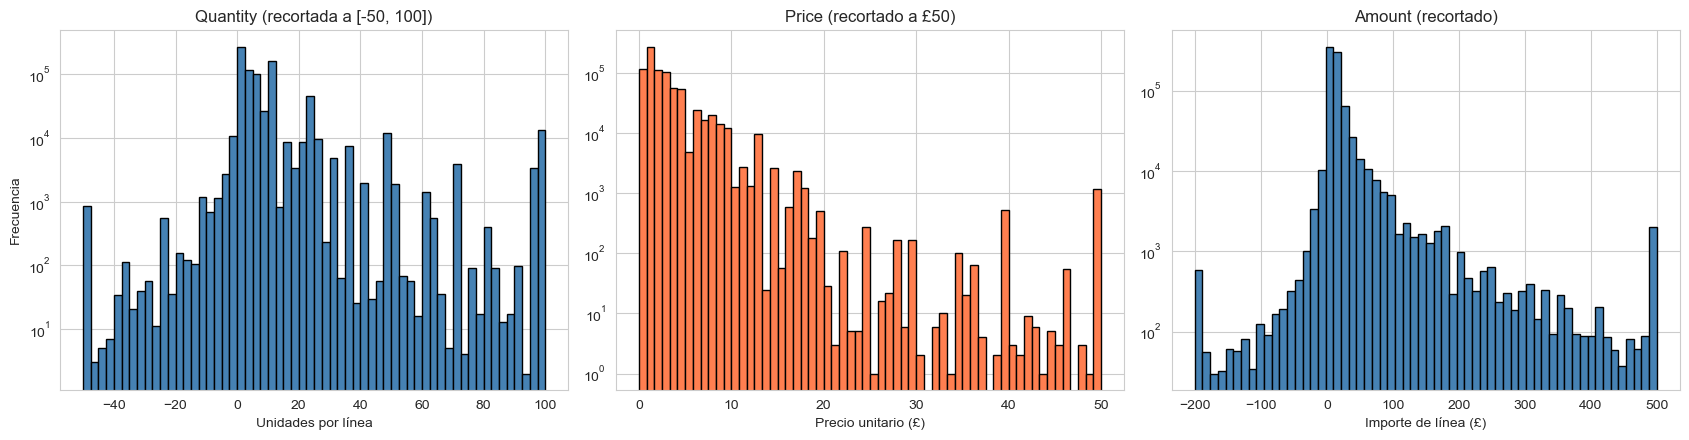

        Quantity      Price     Amount
count  824355.00  824355.00  824355.00
mean       12.41       3.68      20.20
std       188.98      70.24     308.69
min    -80995.00       0.00 -168469.60
25%         2.00       1.25       4.25
50%         5.00       1.95      11.25
75%        12.00       3.75      19.50
max     80995.00   38970.00  168469.60


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(df.Quantity.clip(-50, 100), bins=60, color='steelblue', edgecolor='black')
axes[0].set(xlabel='Unidades por línea', ylabel='Frecuencia',
            title='Quantity (recortada a [-50, 100])', yscale='log')

axes[1].hist(df.loc[df.Price > 0, 'Price'].clip(upper=50), bins=60, color='coral', edgecolor='black')
axes[1].set(xlabel='Precio unitario (£)', title='Price (recortado a £50)', yscale='log')

axes[2].hist(df.Amount.clip(-200, 500), bins=60, color='steelblue', edgecolor='black')
axes[2].set(xlabel='Importe de línea (£)', title='Amount (recortado)', yscale='log')

plt.tight_layout(); plt.show()

print(df[['Quantity', 'Price', 'Amount']].describe().round(2).to_string())

## Comportamiento de los clientes

In [9]:
por_cliente = df.groupby('Customer ID').agg(
    transacciones=('Invoice', 'nunique'), gasto=('Amount', 'sum'),
    devoluciones=('is_return', 'sum'), lineas=('Invoice', 'size'),
)
por_cliente['tasa_devolucion'] = por_cliente.devoluciones / por_cliente.lineas

tramos = pd.cut(por_cliente.transacciones, [0, 1, 5, 20, 10000],
                labels=['1 compra', '2-5', '6-20', '>20'])
resumen = por_cliente.groupby(tramos, observed=False).agg(
    clientes=('gasto', 'size'), gasto_medio=('gasto', 'mean'), gasto_total=('gasto', 'sum'))
resumen['% clientes'] = (resumen.clientes / resumen.clientes.sum() * 100).round(1)
resumen['% ingresos'] = (resumen.gasto_total / resumen.gasto_total.sum() * 100).round(1)

print("Gasto NETO (compras menos devoluciones) por cliente:\n")
print(resumen.round(2).to_string())
print(f"\nLos clientes con más de 20 compras son el {resumen.loc['>20', '% clientes']:.0f}% de la base")
print(f"y aportan el {resumen.loc['>20', '% ingresos']:.0f}% de los ingresos: la concentración")
print("de valor es el rasgo estructural más importante de este negocio.")

Gasto NETO (compras menos devoluciones) por cliente:

               clientes  gasto_medio  gasto_total  % clientes  % ingresos
transacciones                                                            
1 compra           1459       269.81    393648.80        24.6         2.4
2-5                2369       890.99   2110748.13        39.9        12.7
6-20               1695      3196.77   5418531.82        28.5        32.5
>20                 417     20924.13   8725363.64         7.0        52.4

Los clientes con más de 20 compras son el 7% de la base
y aportan el 52% de los ingresos: la concentración
de valor es el rasgo estructural más importante de este negocio.


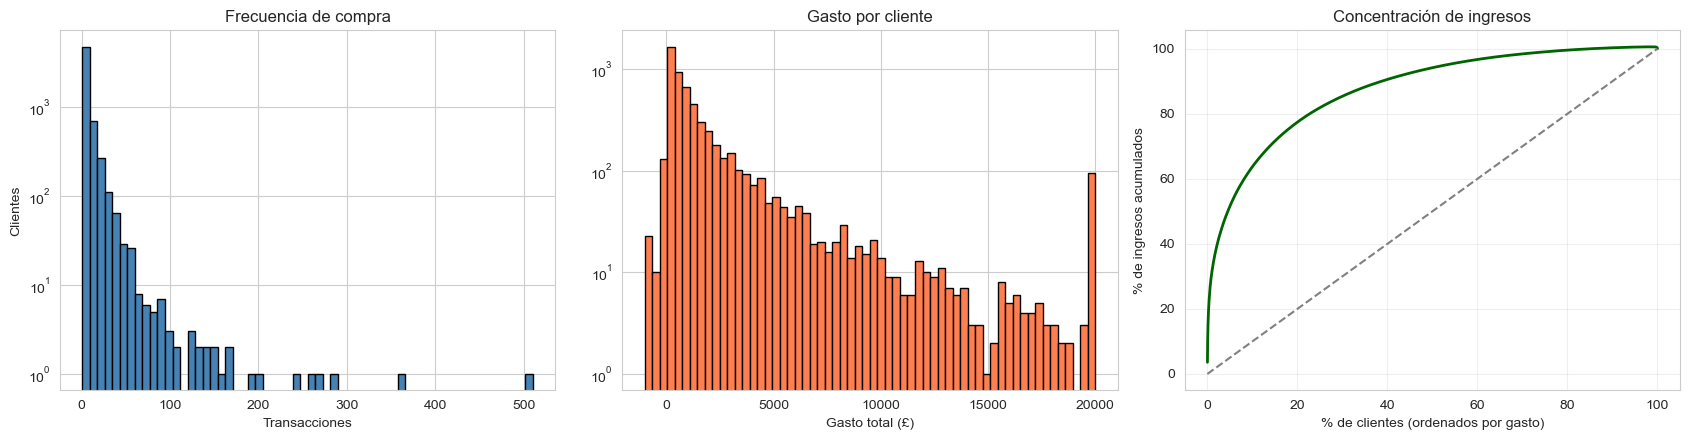

El 20% de los clientes concentra el 77% de los ingresos.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(por_cliente.transacciones, bins=60, color='steelblue', edgecolor='black')
axes[0].set(xlabel='Transacciones', ylabel='Clientes', title='Frecuencia de compra', yscale='log')

axes[1].hist(por_cliente.gasto.clip(-1000, 20000), bins=60, color='coral', edgecolor='black')
axes[1].set(xlabel='Gasto total (£)', title='Gasto por cliente', yscale='log')

acum = por_cliente.gasto.sort_values(ascending=False).cumsum() / por_cliente.gasto.sum()
axes[2].plot(np.arange(1, len(acum) + 1) / len(acum) * 100, acum.values * 100, lw=2, color='darkgreen')
axes[2].plot([0, 100], [0, 100], ls='--', color='gray')
axes[2].set(xlabel='% de clientes (ordenados por gasto)', ylabel='% de ingresos acumulados',
            title='Concentración de ingresos')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

top20 = acum.iloc[int(len(acum) * 0.2)]
print(f"El 20% de los clientes concentra el {top20:.0%} de los ingresos.")

## Evolución temporal

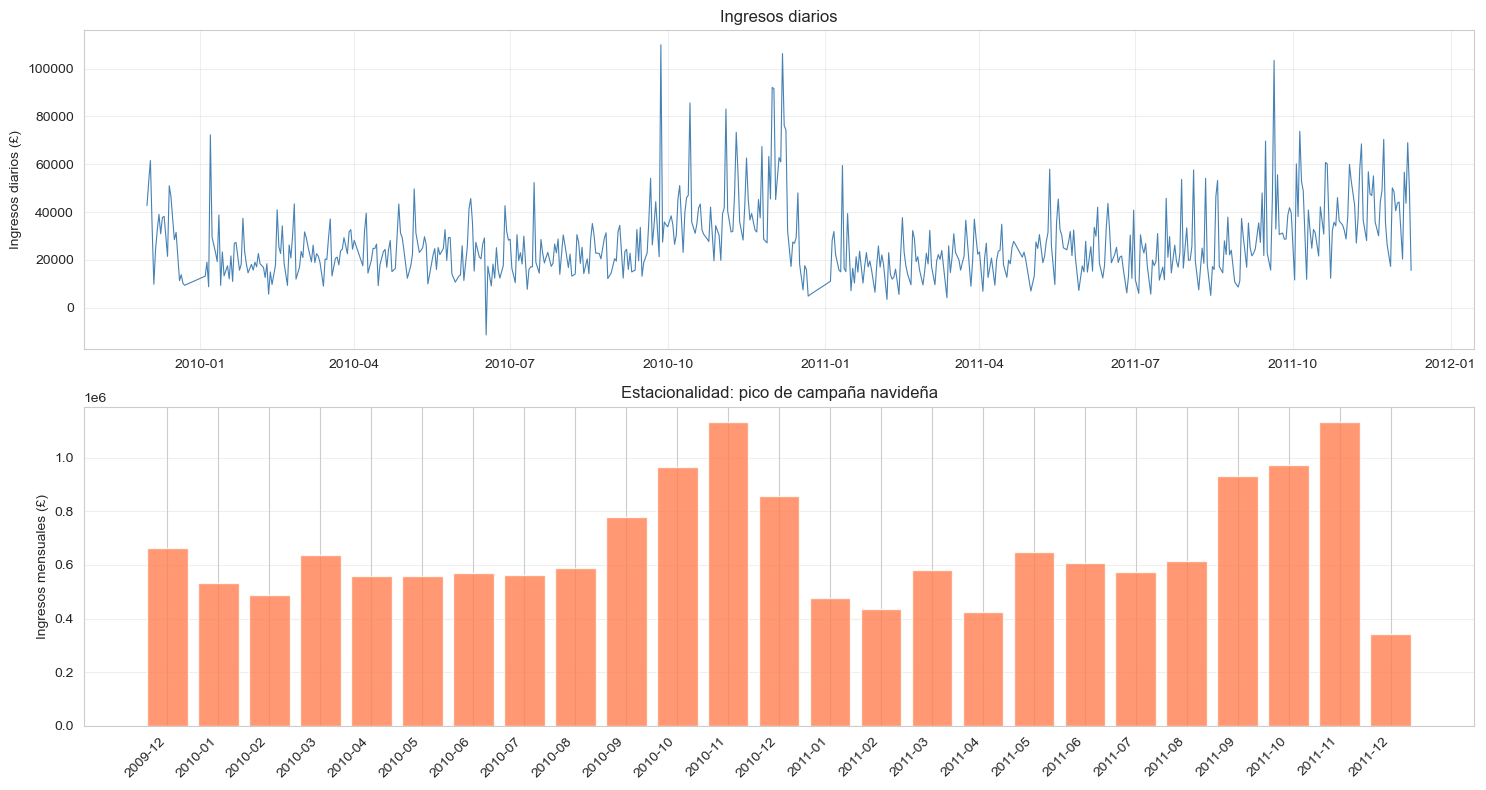

                ingresos  clientes  ticket_medio
InvoiceDate                                     
2009-12       663272.050      1045         635.0
2010-01       531952.902       786         677.0
2010-02       489399.586       805         608.0
2010-03       635996.481      1111         572.0
2010-04       560635.022       998         562.0
2010-05       559924.550      1062         527.0
2010-06       571459.910      1095         522.0
2010-07       562785.900       988         570.0
2010-08       587256.460       964         609.0
2010-09       781033.301      1202         650.0
2010-10       964989.780      1577         612.0
2010-11      1134879.282      1683         674.0
2010-12       859227.370       948         906.0
2011-01       475074.380       783         607.0
2011-02       436546.150       798         547.0
2011-03       579964.610      1020         569.0
2011-04       426047.851       899         474.0
2011-05       648251.080      1079         601.0
2011-06       608013

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

diario = df.groupby(df.InvoiceDate.dt.date).Amount.sum()
axes[0].plot(diario.index, diario.values, lw=0.8, color='steelblue')
axes[0].set(ylabel='Ingresos diarios (£)', title='Ingresos diarios')
axes[0].grid(alpha=0.3)

mensual = df.groupby(df.InvoiceDate.dt.to_period('M')).agg(
    ingresos=('Amount', 'sum'), clientes=('Customer ID', 'nunique'))
axes[1].bar(range(len(mensual)), mensual.ingresos, color='coral', alpha=0.8)
axes[1].set_xticks(range(len(mensual)))
axes[1].set_xticklabels([str(p) for p in mensual.index], rotation=45, ha='right')
axes[1].set(ylabel='Ingresos mensuales (£)', title='Estacionalidad: pico de campaña navideña')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print(mensual.assign(ticket_medio=lambda d: (d.ingresos / d.clientes).round(0)).to_string())

## Esquema de ventanas deslizantes

Una única foto del cliente daría ~5.900 observaciones, insuficiente y sin variación temporal.
En su lugar se observa la base **cada mes**, calculando features con los 6 meses previos y
midiendo el churn en los 90 días siguientes.

El calendario está acotado por los datos: la primera ventana necesita 6 meses de histórico
por detrás y la última necesita 90 días por delante. `observation_calendar()` redondea la
primera fecha **hacia arriba** y la última **hacia abajo**, de modo que ninguna ventana quede
incompleta aunque el dataset no empiece en día 1.

In [12]:
observation_dates = tfm.observation_calendar(df, LOOKBACK_MONTHS, HORIZON_DAYS)

print(f"Datos disponibles : {df.InvoiceDate.min().date()} a {df.InvoiceDate.max().date()}")
print(f"Ventanas          : {len(observation_dates)} "
      f"({observation_dates[0].date()} a {observation_dates[-1].date()})")
print(f"Histórico         : {LOOKBACK_MONTHS} meses · Horizonte: {HORIZON_DAYS} días · Paso: mensual")

# Comprobación explícita de que ninguna ventana queda incompleta, evaluada a nivel de día:
# el primer día con datos cuenta como completo aunque su primera venta sea a las 07:45.
primer_dia, ultimo_dia = df.InvoiceDate.min().normalize(), df.InvoiceDate.max().normalize()
assert observation_dates[0] - pd.DateOffset(months=LOOKBACK_MONTHS) >= primer_dia, \
    "la primera ventana no tiene histórico completo"
assert observation_dates[-1] + pd.Timedelta(days=HORIZON_DAYS) <= ultimo_dia, \
    "la última ventana no tiene horizonte completo"
print("\nCalendario validado: todas las ventanas tienen histórico y horizonte completos.")

Datos disponibles : 2009-12-01 a 2011-12-09
Ventanas          : 16 (2010-06-01 a 2011-09-01)
Histórico         : 6 meses · Horizonte: 90 días · Paso: mensual

Calendario validado: todas las ventanas tienen histórico y horizonte completos.


### Estabilidad del churn entre ventanas

Antes de modelar hay que medir si el fenómeno es estable. **No lo es**, y esa es la conclusión
que condiciona todo lo que viene después: la tasa oscila más de 20 puntos entre ventanas, así
que no existe «la» tasa de abandono de la empresa. De ahí que la Fase 3 valide con un split
temporal —un modelo medido en un solo mes parecería mucho mejor o mucho peor de lo que es— y
que ninguna cifra única sirva como objetivo de retención.

La definición usada aquí es **exactamente** la que aplicará la Fase 2: cliente activo es el que
**compra** (`Quantity > 0`) en la ventana histórica, y vuelve el que **compra** en los 90 días
siguientes. Una devolución no cuenta como actividad en ninguno de los dos bloques.

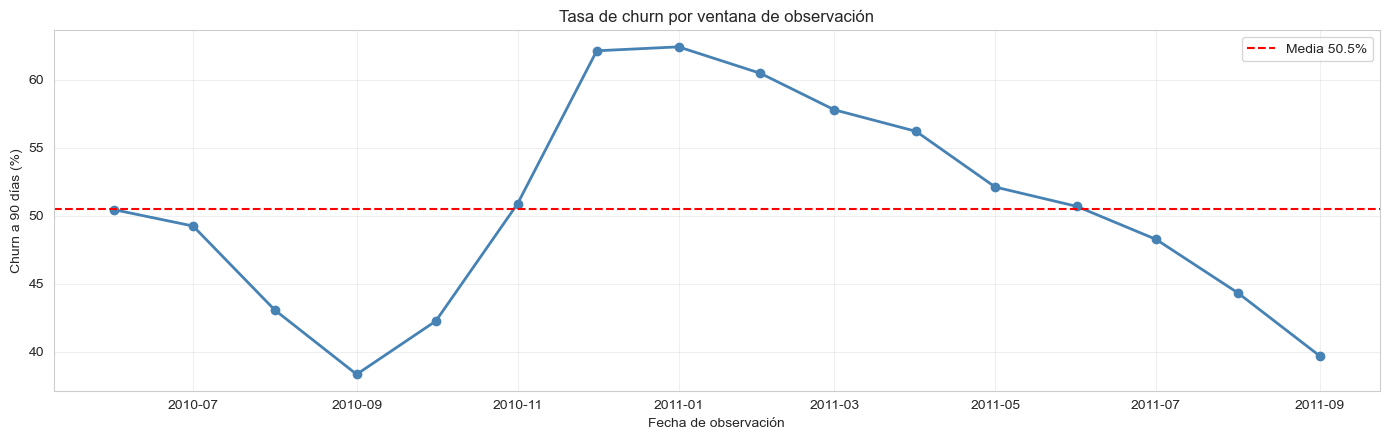

observation_date  clientes_activos  churn_rate
      2010-06-01              2703       0.505
      2010-07-01              2757       0.493
      2010-08-01              2832       0.431
      2010-09-01              2868       0.384
      2010-10-01              2924       0.423
      2010-11-01              3222       0.509
      2010-12-01              3497       0.621
      2011-01-01              3428       0.624
      2011-02-01              3386       0.605
      2011-03-01              3358       0.578
      2011-04-01              3321       0.562
      2011-05-01              3060       0.521
      2011-06-01              2718       0.507
      2011-07-01              2724       0.483
      2011-08-01              2783       0.443
      2011-09-01              2813       0.397

Media 50.5% · desviación 7.7% · rango 38.4%-62.4%

El pico de enero refleja la resaca de la campaña navideña: muchos compradores
estacionales entran en diciembre y no repiten. Es un efecto real del ne

In [13]:
# El churn se mide con la MISMA función que la Fase 2 (`tfm.build_window`), no con una
# reimplementación paralela. La versión anterior contaba «vuelve si existe una línea de
# compra»; el módulo exige «gastó algo». Los regalos y muestras (Price = 0, Quantity > 0)
# caen justo entre ambas definiciones, así que coincidían por cómo son estos datos, no por
# construcción. Con una sola definición, la Fase 1 y la Fase 2 no pueden divergir.
resumen_temporal = []
for obs in observation_dates:
    ventana = tfm.build_window(df, obs, LOOKBACK_MONTHS, HORIZON_DAYS)
    resumen_temporal.append({
        'observation_date': obs, 'clientes_activos': len(ventana),
        'churn_rate': ventana.churn.mean() if len(ventana) else np.nan})

temporal = pd.DataFrame(resumen_temporal)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(temporal.observation_date, temporal.churn_rate * 100, marker='o', lw=2, color='steelblue')
ax.axhline(temporal.churn_rate.mean() * 100, color='red', ls='--',
           label=f'Media {temporal.churn_rate.mean():.1%}')
ax.set(xlabel='Fecha de observación', ylabel='Churn a 90 días (%)',
       title='Tasa de churn por ventana de observación')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(temporal.assign(observation_date=temporal.observation_date.dt.date).round(3).to_string(index=False))
print(f"\nMedia {temporal.churn_rate.mean():.1%} · desviación {temporal.churn_rate.std():.1%} · "
      f"rango {temporal.churn_rate.min():.1%}-{temporal.churn_rate.max():.1%}")
print("\nEl pico de enero refleja la resaca de la campaña navideña: muchos compradores")
print("estacionales entran en diciembre y no repiten. Es un efecto real del negocio, no ruido,")
print("y justifica que el split de validación sea temporal y no aleatorio.")

## RFM de referencia

Foto única en la última fecha disponible, como punto de comparación para las métricas por
ventana de la Fase 2. Se calcula sobre líneas de compra, igual que en la Fase 2.

In [14]:
corte = df.InvoiceDate.max()
compras = df[df.Quantity > 0]
rfm = compras.groupby('Customer ID').agg(
    ultima_compra=('InvoiceDate', 'max'), primera_compra=('InvoiceDate', 'min'),
    Frequency=('Invoice', 'nunique'), Monetary=('Amount', 'sum'))
rfm['Recency'] = (corte - rfm.ultima_compra).dt.days

print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(1).to_string())

tramos_r = pd.cut(rfm.Recency, [0, 30, 90, 180, 10000],
                  labels=['< 30 días', '30-90', '90-180', '> 180'], right=False)
print(f"\n{(rfm.groupby(tramos_r, observed=False).size() / len(rfm) * 100).round(1).to_frame('% clientes').to_string()}")

       Recency  Frequency  Monetary
count   5879.0     5879.0    5879.0
mean     200.3        6.3    3018.1
std      209.3       13.0   14736.5
min        0.0        1.0       0.0
25%       25.0        1.0     348.7
50%       95.0        3.0     898.9
75%      379.0        7.0    2306.1
max      738.0      398.0  608821.6

           % clientes
Recency              
< 30 días        28.0
30-90            21.1
90-180           10.0
> 180            40.8


## Guardar

In [15]:
calidad['n_ventanas'] = len(observation_dates)
calidad['churn_min_pct'] = round(temporal.churn_rate.min() * 100, 1)
calidad['churn_max_pct'] = round(temporal.churn_rate.max() * 100, 1)

df.to_csv('../data/processed/online_retail_II_cleaned.csv', index=False)
pd.DataFrame({'observation_date': observation_dates}).to_csv('../data/processed/observation_dates.csv', index=False)
temporal.to_csv('../outputs/fase1_eda/temporal_analysis_summary.csv', index=False)
rfm.to_csv('../data/processed/rfm_base.csv')
(pd.Series(calidad, name='valor').rename_axis('metrica')
 .to_csv('../outputs/fase1_eda/data_quality_fase1.csv'))

for f in ['../data/processed/online_retail_II_cleaned.csv', '../data/processed/observation_dates.csv',
          '../outputs/fase1_eda/temporal_analysis_summary.csv', '../data/processed/rfm_base.csv', '../outputs/fase1_eda/data_quality_fase1.csv']:
    print(f)

../data/processed/online_retail_II_cleaned.csv
../data/processed/observation_dates.csv
../outputs/fase1_eda/temporal_analysis_summary.csv
../data/processed/rfm_base.csv
../outputs/fase1_eda/data_quality_fase1.csv
